  Projective Transformation (Homography) – Billboard Demo

Manual_Homography_Config_1
Destination Points: [[160, 85], [256, 112], [250, 250], [140, 240]]
Homography Matrix (3x3):
[[ 3.25222505e-01 -9.22582046e-02  1.60000000e+02]
 [ 1.04690861e-01  3.16243364e-01  8.50000000e+01]
 [ 3.30550786e-04 -3.00949223e-04  1.00000000e+00]]
Determinant: 0.09646872210811525

Manual_Homography_Config_2
Destination Points: [[140, 60], [280, 100], [270, 270], [110, 265]]
Homography Matrix (3x3):
[[ 4.97666184e-01 -1.06044929e-01  1.40000000e+02]
 [ 1.52675266e-01  4.39447242e-01  6.00000000e+01]
 [ 5.24246396e-04 -2.80517808e-04  1.00000000e+00]]
Determinant: 0.2016801560185334


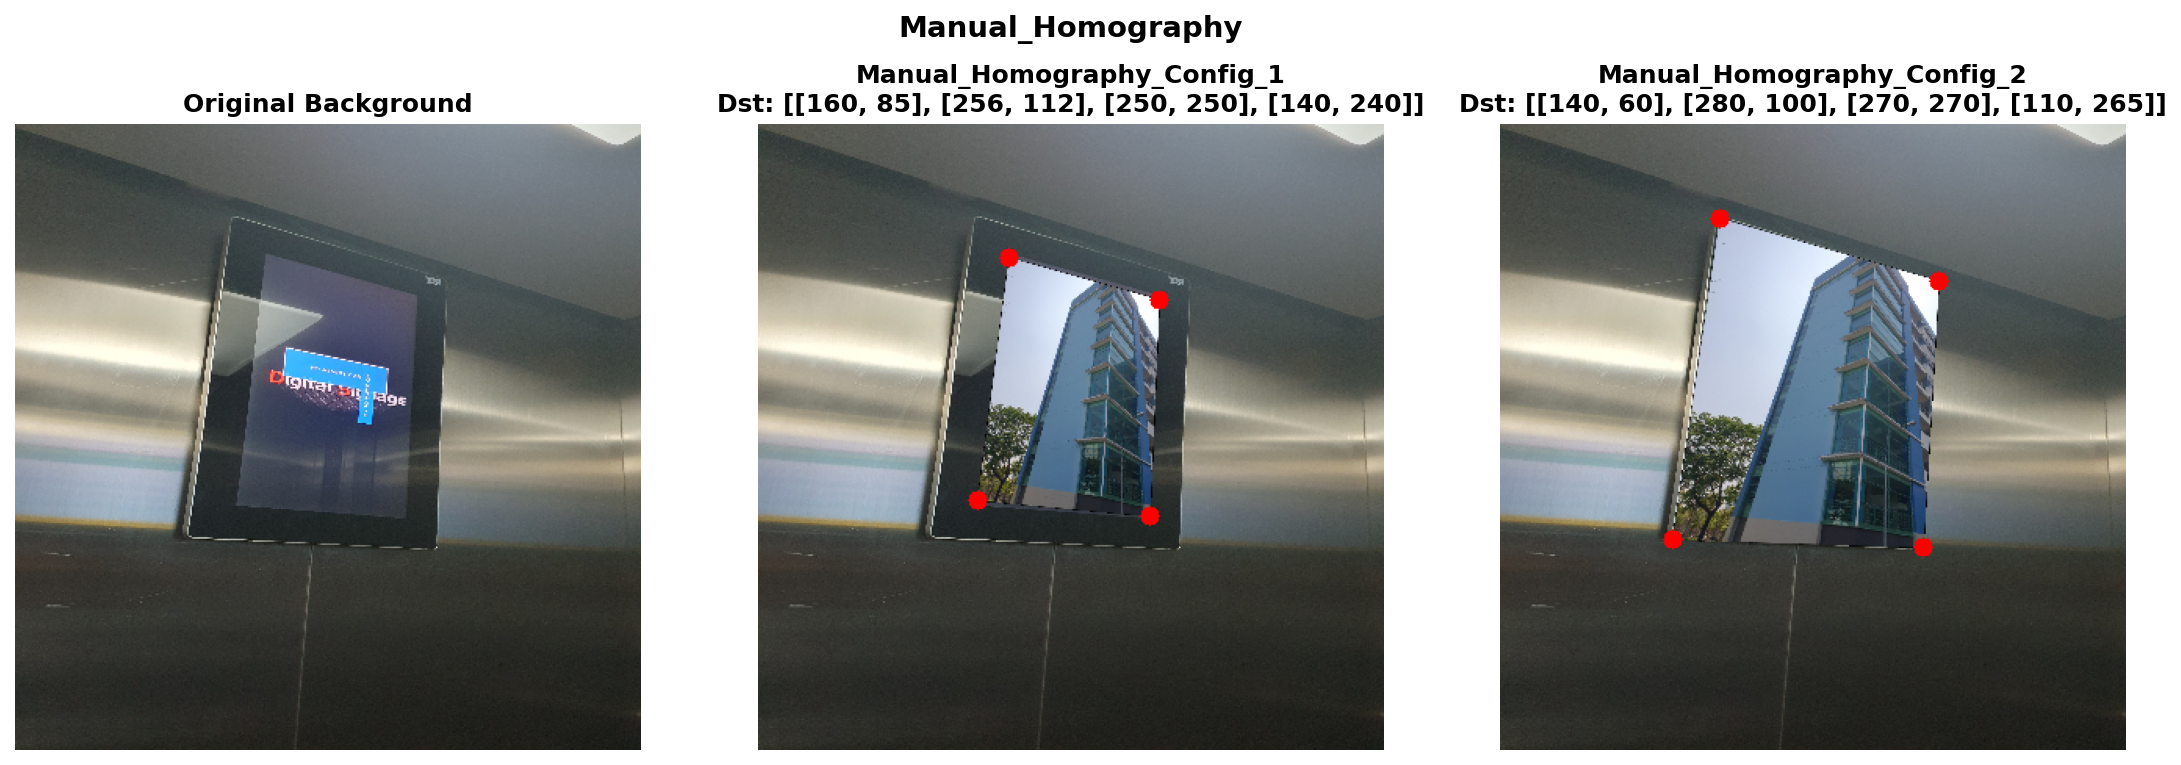

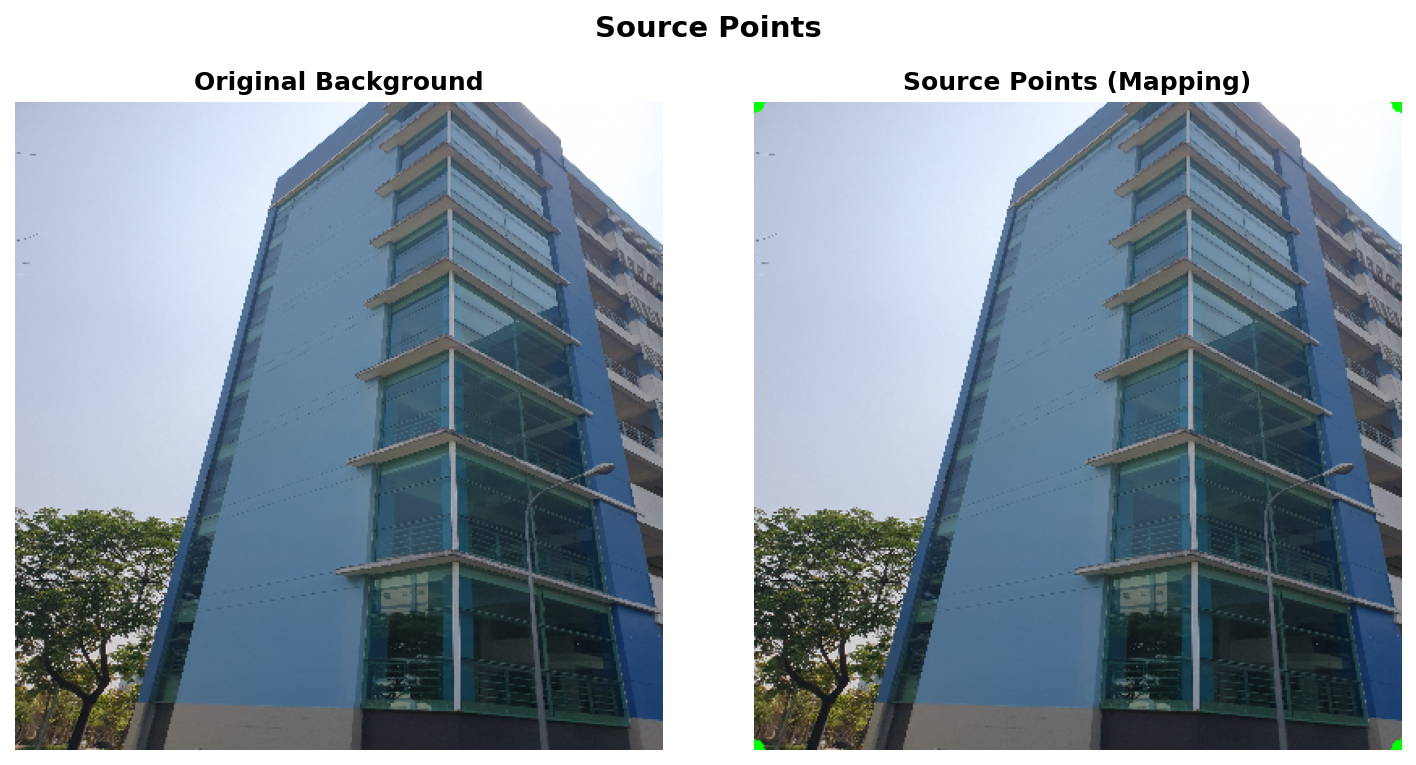

[DONE] Kết quả đã lưu vào thư mục output.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import display
from PIL import Image

# =============================================================================
# CONFIGURATION
# =============================================================================
IMAGE_PATH_1 = "./input/bg1.jpg" 
IMAGE_PATH_2 = "./input/bg2.jpg" 
OUTPUT_DIR = "output/homography_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = (400, 400)
FIG_DPI  = 150

# =============================================================================
# UTILITY FUNCTIONS 
# =============================================================================

def save_and_show(img_bgr, filename=None, title=""):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)
    
    if filename is not None:
        path = os.path.join(OUTPUT_DIR, filename)
        pil_img.save(path)
        print(f"[SAVED] {path}")
    
    if title:
        print(title)
    display(pil_img)

def visualize_all(original, results_dict, filename='homo_results.png', suptitle='Projective Transformation Demo', cols=3):
    """Trực quan hóa tổng hợp các kết quả trong cùng một figure."""
    titles = list(results_dict.keys())
    imgs   = list(results_dict.values())

    n = len(imgs) + 1
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5), dpi=FIG_DPI)
    axes = axes.flatten()

    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Background', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    for i, (title, img) in enumerate(zip(titles, imgs), start=1):
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(title, fontsize=12, fontweight='bold')
        axes[i].axis('off')

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=1.01)
    fig.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, bbox_inches='tight')
    display(fig)
    plt.close(fig)

# =============================================================================
# PROJECTIVE TRANSFORMATION (HOMOGRAPHY)
# =============================================================================

def projective_from_points(img_src, img_bg, dst_pts):
    """
    img_src  : Ảnh nguồn bg2 
    img_bg   : Ảnh nền bg1 
    dst_pts  : List 4 điểm đích trên ảnh nền [[x1,y1],[x2,y2],[x3,y3],[x4,y4]]

    Returns:
        img_src_drawn  : Ảnh nguồn có vẽ 4 điểm xanh lá (Input)
        img_res_drawn  : Ảnh nền đã dán có vẽ 4 điểm đỏ (Output)
        H              : Ma trận Homography (3x3)
    """
    src_pts = np.array([[0, 0], [img_src.shape[1]-1, 0], 
                        [img_src.shape[1]-1, img_src.shape[0]-1], 
                        [0, img_src.shape[0]-1]], dtype=np.float32)
    dst_pts = np.array(dst_pts, dtype=np.float32)

    if src_pts.shape != (4, 2) or dst_pts.shape != (4, 2):
        raise ValueError("Cần đúng chính xác 4 điểm SRC và 4 điểm DST")

    # 1. Tìm ma trận Homography (3x3) 
    H = cv2.getPerspectiveTransform(src_pts, dst_pts)
    

    # 2. Warp Perspective 
    h_b, w_b = img_bg.shape[:2]
    warped = cv2.warpPerspective(img_src, H, (w_b, h_b))

    # 3. Masking
    mask = np.zeros((h_b, w_b), dtype=np.uint8)
    cv2.fillConvexPoly(mask, dst_pts.astype(int), 255)
    img_bg_hole = cv2.bitwise_and(img_bg, img_bg, mask=cv2.bitwise_not(mask))
    result = cv2.add(img_bg_hole, warped)

    # 4. Vẽ điểm lên ảnh nguồn 
    img_src_drawn = img_src.copy()
    for pt in src_pts:
        cv2.circle(img_src_drawn, tuple(pt.astype(int)), 6, (0, 255, 0), -1)

    # 5. Vẽ điểm lên ảnh kết quả 
    img_res_drawn = result.copy()
    for pt in dst_pts:
        cv2.circle(img_res_drawn, tuple(pt.astype(int)), 6, (0, 0, 255), -1)

    return img_src_drawn, img_res_drawn, H

def run_projective_configs(img_src, img_bg, dst_configs, prefix_name):
    """Hàm chạy demo nhiều cấu hình Projective."""
    results = {} 
    for i, dst_pts in enumerate(dst_configs):
        config_name = f"{prefix_name}_Config_{i+1}"

        img_s_drawn, img_r_drawn, H_mat = projective_from_points(img_src, img_bg, dst_pts)
        
        title = f"{config_name}\nDst: {dst_pts}"
        results[title] = img_r_drawn

        print("\n" + "="*60)
        print(config_name)
        print("Destination Points:", dst_pts)
        print("Homography Matrix (3x3):")
        print(H_mat)
        print(f"Determinant: {np.linalg.det(H_mat)}")
        print("="*60)

    visualize_all(img_bg, results, f"{prefix_name}_Results.png", prefix_name)
    
    # Hiển thị ảnh nguồn (Mapping)
    results_src = { "Source Points (Mapping)": img_s_drawn }
    visualize_all(img_src, results_src, f"{prefix_name}_Src.png", "Source Points", 2)

# =============================================================================
# MAIN PIPELINE
# =============================================================================

def main():
    print("=" * 60)
    print("  Projective Transformation (Homography) – Billboard Demo")
    print("=" * 60)

    # 1. Khởi tạo ảnh
    bg = cv2.resize(cv2.imread(IMAGE_PATH_1), IMG_SIZE)
    src = cv2.resize(cv2.imread(IMAGE_PATH_2), IMG_SIZE)
    
    if bg is None or src is None:
        raise FileNotFoundError("Kiểm tra lại đường dẫn IMAGE_PATH_1/2.")

    # 2. Thủ công (Manual Mapping)
    # Xác định tọa độ 4 góc biển quảng cáo trên bg1 (TL, TR, BR, BL)
    manual_configs = [
    # Config 1
    [
        [160, 85], # Điểm 1 (TL) 
        [256, 112], # Điểm 2 (TR) 
        [250, 250], # Điểm 3 (BR) 
        [140, 240]  # Điểm 4 (BL) 
    ],
    
    # Config 2
    [
        [140, 60],   # TL
        [280, 100],  # TR
        [270, 270], # BR
        [110, 265]   # BL
    ]
]
    run_projective_configs(src, bg, manual_configs, "Manual_Homography")

    print("[DONE] Kết quả đã lưu vào thư mục output.")

if __name__ == "__main__":
    main()